In [3]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_excel(filename, sheet_name='Sheet1')
df.columns = ['Date', 'KLBF', 'MIKA', 'HEAL']
df['Date'] = pd.to_datetime(df['Date'])  # langsung, tanpa unit/origin
df = df.sort_values('Date').reset_index(drop=True)

print("✅ Data berhasil dimuat!")
print(f"Periode: {df['Date'].min().date()} s.d. {df['Date'].max().date()}")
print(f"Total data: {len(df)} baris")
print(df.head())

Saving FIKSSS_FP_MANRISK.xlsx to FIKSSS_FP_MANRISK (1).xlsx
✅ Data berhasil dimuat!
Periode: 2025-06-12 s.d. 2026-06-12
Total data: 240 baris
        Date  KLBF  MIKA  HEAL
0 2025-06-12  1535  2500  1385
1 2025-06-13  1530  2550  1380
2 2025-06-16  1530  2600  1395
3 2025-06-17  1595  2500  1395
4 2025-06-18  1550  2500  1410


In [4]:
emiten = ['KLBF', 'MIKA', 'HEAL']

returns = np.log(df[emiten] / df[emiten].shift(1)).dropna()
returns.index = df['Date'][1:].values

print("✅ Return harian berhasil dihitung!")
print(returns.describe().round(6))

✅ Return harian berhasil dihitung!
             KLBF        MIKA        HEAL
count  239.000000  239.000000  239.000000
mean    -0.003053   -0.002054   -0.002067
std      0.023648    0.020846    0.021028
min     -0.055451   -0.070551   -0.110256
25%     -0.019465   -0.013401   -0.011959
50%     -0.004090   -0.003738    0.000000
75%      0.010042    0.008962    0.007420
max      0.092373    0.067620    0.060625


   VaR VARIANCE-COVARIANCE — CL 95% — Rp 1.000.000.000

📌 KLBF
   Mean Return (μ)   : -0.003053
   Std Dev   (σ)     : 0.023648
   VaR (Rp)          : Rp 41,951,242.20
   VaR (%)           : 4.1951%


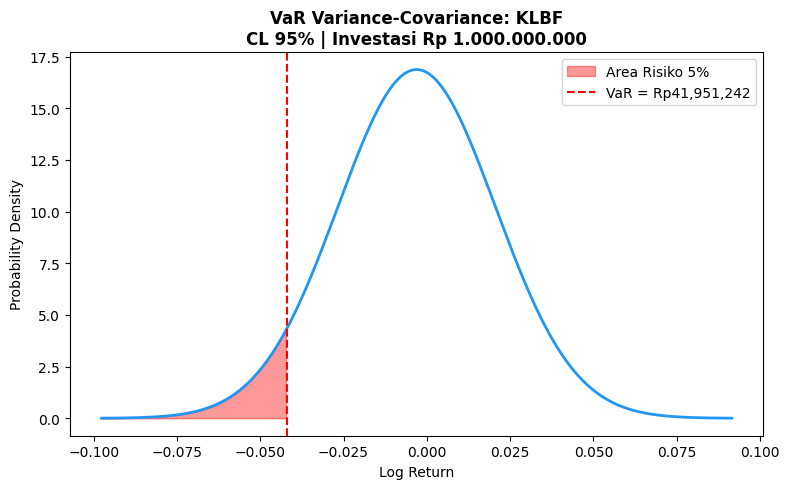

✅ Grafik KLBF tersimpan.

📌 MIKA
   Mean Return (μ)   : -0.002054
   Std Dev   (σ)     : 0.020846
   VaR (Rp)          : Rp 36,343,927.53
   VaR (%)           : 3.6344%


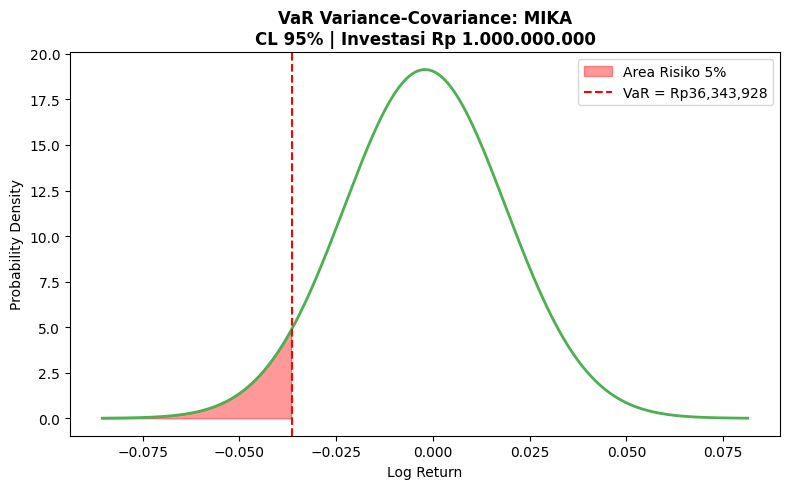

✅ Grafik MIKA tersimpan.

📌 HEAL
   Mean Return (μ)   : -0.002067
   Std Dev   (σ)     : 0.021028
   VaR (Rp)          : Rp 36,656,754.61
   VaR (%)           : 3.6657%


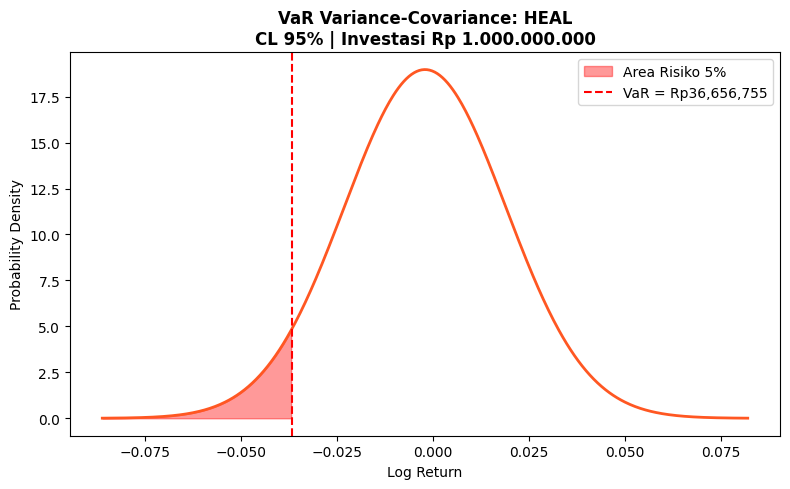

✅ Grafik HEAL tersimpan.


In [5]:
INVESTASI  = 1_000_000_000
CL         = 0.95
Z          = 1.6449

print("=" * 60)
print("   VaR VARIANCE-COVARIANCE — CL 95% — Rp 1.000.000.000")
print("=" * 60)

hasil_vc = {}
colors = ['#2196F3', '#4CAF50', '#FF5722']

for i, ticker in enumerate(emiten):
    mu     = returns[ticker].mean()
    sigma  = returns[ticker].std()
    var_rp = abs(INVESTASI * (mu - Z * sigma))
    var_pct = var_rp / INVESTASI * 100
    hasil_vc[ticker] = var_rp

    print(f"\n📌 {ticker}")
    print(f"   Mean Return (μ)   : {mu:.6f}")
    print(f"   Std Dev   (σ)     : {sigma:.6f}")
    print(f"   VaR (Rp)          : Rp {var_rp:,.2f}")
    print(f"   VaR (%)           : {var_pct:.4f}%")

    # Grafik per emiten
    x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
    y_range = stats.norm.pdf(x_range, mu, sigma)
    cutoff  = mu - Z * sigma

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_range, y_range, color=colors[i], linewidth=2)
    ax.fill_between(x_range, y_range, where=(x_range <= cutoff),
                    color='red', alpha=0.4, label='Area Risiko 5%')
    ax.axvline(cutoff, color='red', linestyle='--', linewidth=1.5,
               label=f'VaR = Rp{var_rp:,.0f}')
    ax.set_title(f'VaR Variance-Covariance: {ticker}\nCL 95% | Investasi Rp 1.000.000.000',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Probability Density')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'var_vc_{ticker}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Grafik {ticker} tersimpan.")

   VaR MONTE CARLO — CL 95% — Rp 1.000.000.000
   Jumlah Simulasi: 50,000

📌 KLBF
   VaR Monte Carlo (Rp) : Rp 41,766,078.83
   VaR Monte Carlo (%)  : 4.1766%


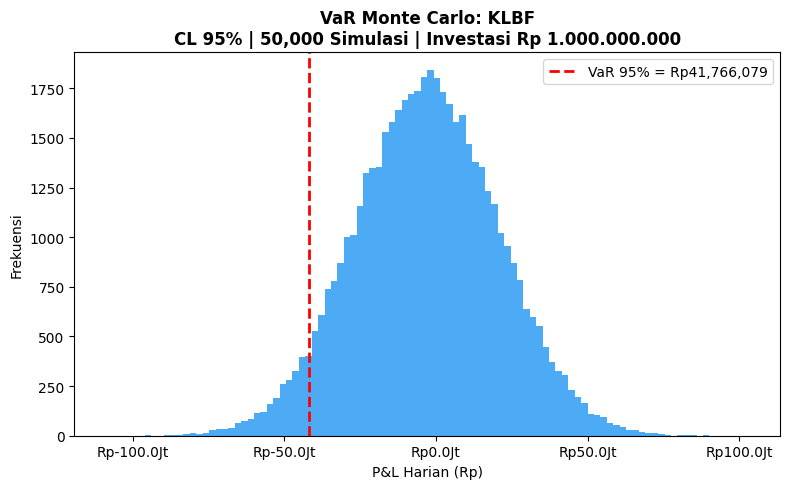

✅ Grafik KLBF tersimpan.

📌 MIKA
   VaR Monte Carlo (Rp) : Rp 36,411,671.80
   VaR Monte Carlo (%)  : 3.6412%


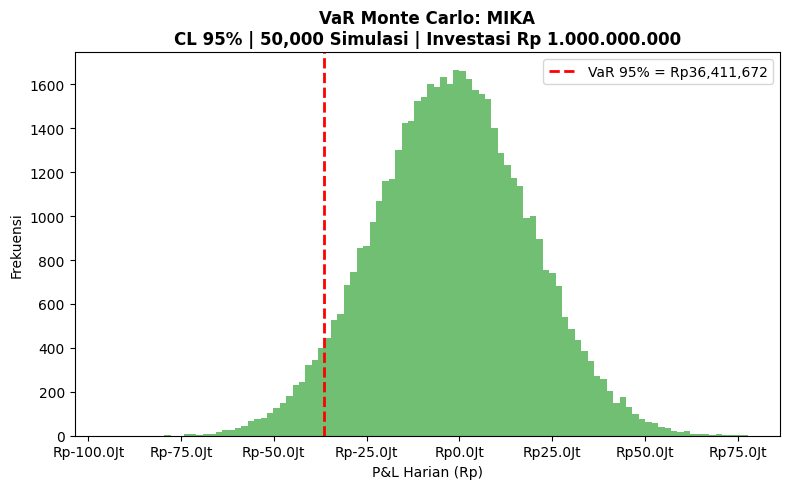

✅ Grafik MIKA tersimpan.

📌 HEAL
   VaR Monte Carlo (Rp) : Rp 36,551,866.38
   VaR Monte Carlo (%)  : 3.6552%


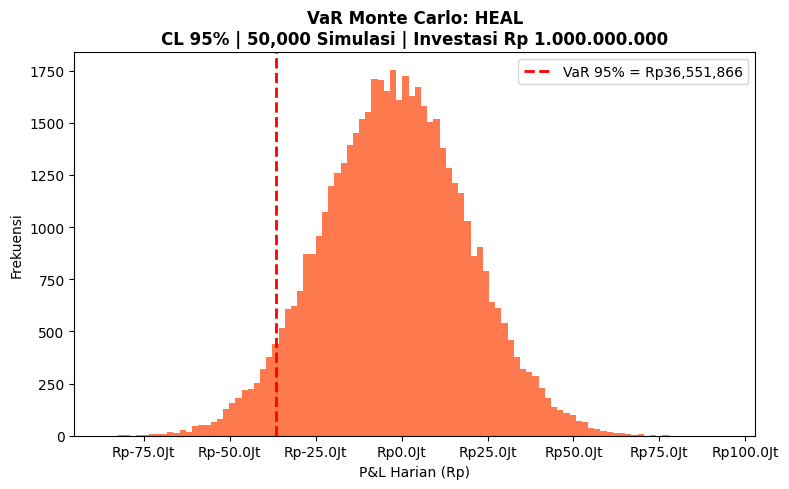

✅ Grafik HEAL tersimpan.


In [6]:
N_SIMULASI = 50_000
np.random.seed(42)

print("=" * 60)
print("   VaR MONTE CARLO — CL 95% — Rp 1.000.000.000")
print(f"   Jumlah Simulasi: {N_SIMULASI:,}")
print("=" * 60)

hasil_mc = {}

for i, ticker in enumerate(emiten):
    mu    = returns[ticker].mean()
    sigma = returns[ticker].std()

    sim_returns = np.random.normal(mu, sigma, N_SIMULASI)
    sim_pnl     = INVESTASI * sim_returns

    var_rp  = abs(np.percentile(sim_pnl, 5))
    var_pct = var_rp / INVESTASI * 100
    hasil_mc[ticker] = var_rp

    print(f"\n📌 {ticker}")
    print(f"   VaR Monte Carlo (Rp) : Rp {var_rp:,.2f}")
    print(f"   VaR Monte Carlo (%)  : {var_pct:.4f}%")

    # Grafik per emiten
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(sim_pnl, bins=100, color=colors[i], edgecolor='none', alpha=0.8)
    ax.axvline(-var_rp, color='red', linewidth=2, linestyle='--',
               label=f'VaR 95% = Rp{var_rp:,.0f}')
    ax.set_title(f'VaR Monte Carlo: {ticker}\nCL 95% | {N_SIMULASI:,} Simulasi | Investasi Rp 1.000.000.000',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('P&L Harian (Rp)')
    ax.set_ylabel('Frekuensi')
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'Rp{x/1e6:.1f}Jt'))
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'var_mc_{ticker}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Grafik {ticker} tersimpan.")

   PERBANDINGAN VaR CL 95% — Investasi Rp 1.000.000.000
Emiten              Var-Cov (Rp)      Monte Carlo (Rp)         Selisih
-----------------------------------------------------------------
KLBF               41,951,242.20         41,766,078.83     -185,163.37
MIKA               36,343,927.53         36,411,671.80      +67,744.27
HEAL               36,656,754.61         36,551,866.38     -104,888.23


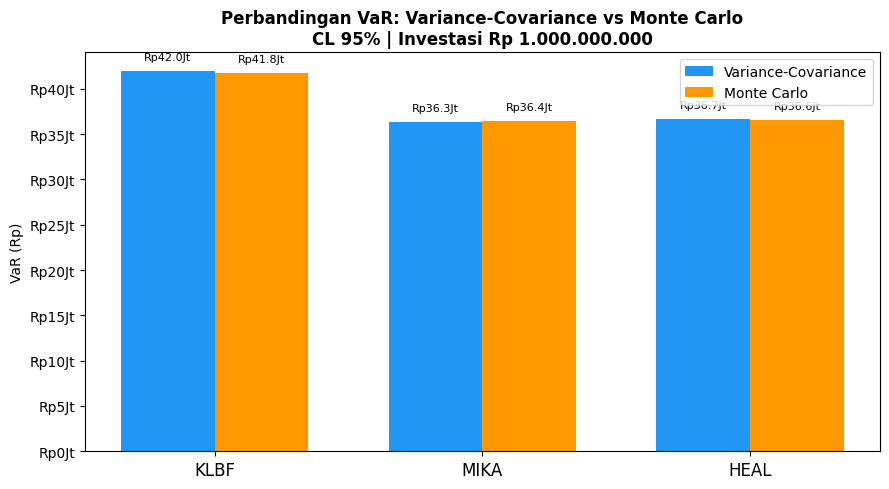

✅ Selesai!


In [7]:
x  = np.arange(len(emiten))
bw = 0.35

print("=" * 65)
print("   PERBANDINGAN VaR CL 95% — Investasi Rp 1.000.000.000")
print("=" * 65)
print(f"{'Emiten':<10}  {'Var-Cov (Rp)':>20}  {'Monte Carlo (Rp)':>20}  {'Selisih':>14}")
print("-" * 65)
for ticker in emiten:
    vc  = hasil_vc[ticker]
    mc  = hasil_mc[ticker]
    print(f"{ticker:<10}  {vc:>20,.2f}  {mc:>20,.2f}  {mc-vc:>+14,.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - bw/2, [hasil_vc[t] for t in emiten], bw,
            label='Variance-Covariance', color='#2196F3')
b2 = ax.bar(x + bw/2, [hasil_mc[t] for t in emiten], bw,
            label='Monte Carlo',         color='#FF9800')

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1e6,
                f'Rp{bar.get_height()/1e6:.1f}Jt',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(emiten, fontsize=12)
ax.set_ylabel('VaR (Rp)')
ax.set_title('Perbandingan VaR: Variance-Covariance vs Monte Carlo\n'
             'CL 95% | Investasi Rp 1.000.000.000', fontsize=12, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'Rp{x/1e6:.0f}Jt'))
plt.tight_layout()
plt.savefig('perbandingan_var.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Selesai!")

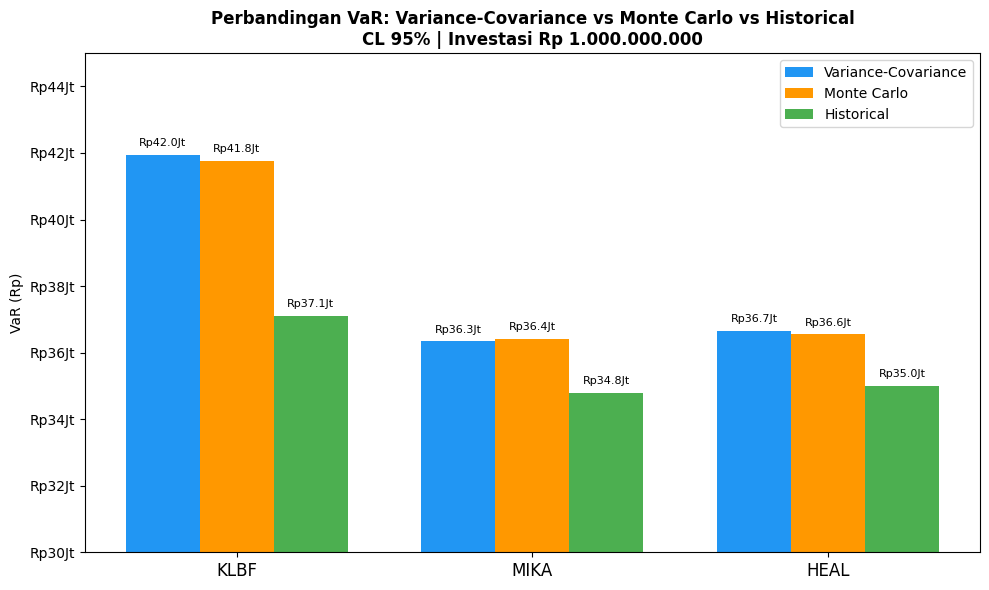

In [8]:
import matplotlib.pyplot as plt
import numpy as np

emiten = ['KLBF', 'MIKA', 'HEAL']
var_vc  = [41_951_242, 36_343_928, 36_656_755]
var_mc  = [41_766_079, 36_411_672, 36_551_866]
var_his = [37_100_000, 34_800_000, 35_000_000]

x  = np.arange(len(emiten))
bw = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - bw, var_vc,  bw, label='Variance-Covariance', color='#2196F3')
b2 = ax.bar(x,      var_mc,  bw, label='Monte Carlo',          color='#FF9800')
b3 = ax.bar(x + bw, var_his, bw, label='Historical',           color='#4CAF50')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200_000,
                f'Rp{bar.get_height()/1e6:.1f}Jt',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(emiten, fontsize=12)
ax.set_ylabel('VaR (Rp)')
ax.set_title('Perbandingan VaR: Variance-Covariance vs Monte Carlo vs Historical\n'
             'CL 95% | Investasi Rp 1.000.000.000', fontsize=12, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp{x/1e6:.0f}Jt'))
ax.set_ylim(30_000_000, 45_000_000)
plt.tight_layout()
plt.savefig('perbandingan_3metode.png', dpi=150, bbox_inches='tight')
plt.show()